  Preparing metadata (setup.py) ... done
Cloning into '/content/kits23'...
remote: Enumerating objects: 15613, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 15613 (delta 21), reused 14 (delta 14), pack-reused 15585 (from 2)
Receiving objects: 100% (15613/15613), 493.98 MiB | 19.93 MiB/s, done.
Resolving deltas: 100% (14012/14012), done.
Updating files: 100% (5720/5720), done.
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 8.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 11.8 MB/s eta 0:00:00

Found 489 cases to download

Dowloading case_00033...:   7% 33/489 [03:32<41:36,  5.47s/it]
Failed to download case_00033. Retrying...
Dowloading case_00033...:   7% 33/489 [05:27<1:15:19,  

Converting KiTS23 volumes: 100%|██████████| 489/489 [01:41<00:00,  4.82it/s]


Tumor slice extraction complete
Cases with segmentations used: 34
Cases skipped (missing seg): 455
Tumor-positive PNG slices saved: 1987
Image PNG count: 1987
Mask  PNG count: 1987



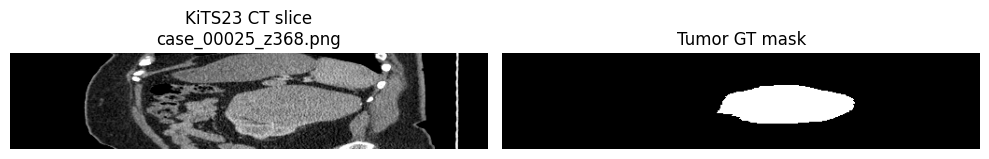

Sample file: case_00025_z368.png  Tumor pixels: 4592
Using device: cuda
GPU: NVIDIA A100-SXM4-80GB


Quick SAM test: 100%|██████████| 50/50 [00:07<00:00,  6.96it/s]



Quick test summary:
            dice        iou
count  50.000000  50.000000
mean    0.767510   0.659333
std     0.220321   0.211666
min     0.012356   0.006216
25%     0.802204   0.669733
50%     0.847959   0.736049
75%     0.873647   0.775659
max     0.924242   0.859155


Full SAM evaluation: 100%|██████████| 1987/1987 [03:33<00:00,  9.30it/s]



Saved: /content/kits23_sam_project/kits23_tumor_sam_boxprompt_metrics.csv
              dice          iou
count  1987.000000  1987.000000
mean      0.837443     0.740106
std       0.140164     0.167827
min       0.000000     0.000000
25%       0.793349     0.657481
50%       0.869863     0.769697
75%       0.923809     0.858406
max       1.000000     1.000000

Failure rate (Dice < 0.5): 3.47 %
Severe failure (Dice < 0.1): 0.75 %

Worst 10 slices:
                     file      dice       iou
1957  case_00033_z170.png  0.000000  0.000000
959   case_00018_z157.png  0.000000  0.000000
600   case_00012_z289.png  0.000000  0.000000
1461  case_00026_z179.png  0.000000  0.000000
1891  case_00030_z452.png  0.000000  0.000000
997   case_00018_z195.png  0.000000  0.000000
449   case_00009_z288.png  0.000000  0.000000
1125  case_00023_z155.png  0.000000  0.000000
1014  case_00019_z353.png  0.000000  0.000000
49    case_00001_z121.png  0.012356  0.006216


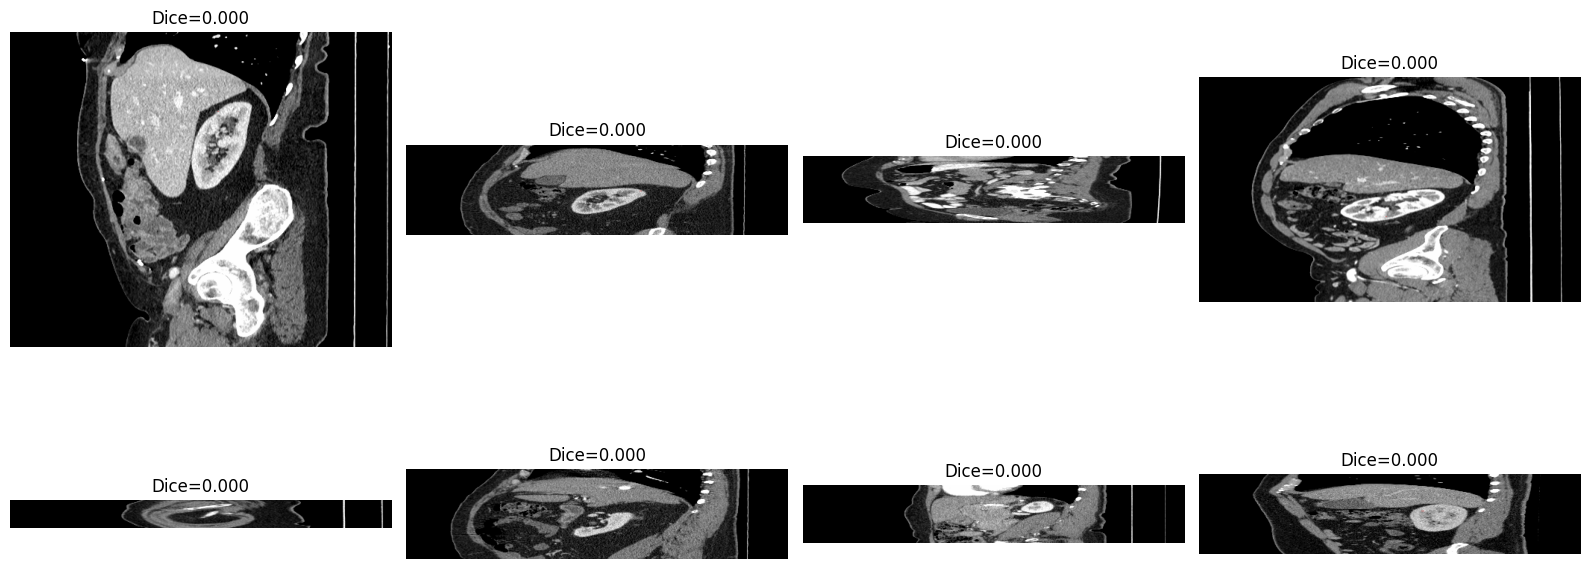

Saved: /content/kits23_sam_project/kits23_tumor_worst_cases_overlay.png


Robustness evaluation: 100%|██████████| 1987/1987 [38:24<00:00,  1.16s/it]



Saved: /content/kits23_sam_project/kits23_tumor_sam_robustness_results.csv

Robustness summary:
        condition  mean_dice  mean_iou  mean_delta_dice  mean_delta_iou  \
5    down_up_0.25   0.800371  0.682284        -0.037072       -0.057823   
1         blur_k7   0.818418  0.709728        -0.019025       -0.030378   
6     down_up_0.5   0.827795  0.723483        -0.009647       -0.016624   
0         blur_k3   0.831258  0.730272        -0.006184       -0.009834   
7       gamma_0.8   0.836224  0.738180        -0.001218       -0.001926   
10  noise_sigma25   0.836516  0.737709        -0.000927       -0.002397   
9   noise_sigma10   0.836926  0.738762        -0.000517       -0.001344   
2           clean   0.837443  0.740106         0.000000        0.000000   
3    contrast_0.8   0.838404  0.741491         0.000962        0.001384   
8       gamma_1.2   0.838570  0.741758         0.001128        0.001651   
4    contrast_1.2   0.839628  0.742820         0.002185        0.002714   

  

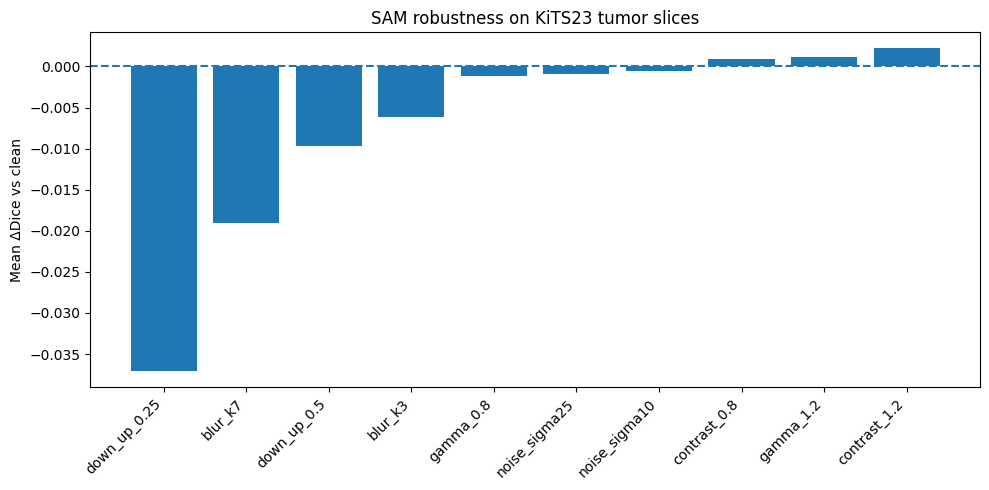

Saved: /content/kits23_sam_project/kits23_tumor_robustness_barplot.png
Saved: /content/kits23_sam_project/kits23_tumor_summary.txt

✅ ALL DONE
Main output folder: /content/kits23_sam_project
Files inside:
 - images
 - kits23_tumor_robustness_barplot.png
 - kits23_tumor_robustness_summary_table.csv
 - kits23_tumor_sam_boxprompt_metrics.csv
 - kits23_tumor_sam_robustness_results.csv
 - kits23_tumor_summary.txt
 - kits23_tumor_worst_cases_overlay.png
 - masks
 - preds

ZIP ready at: /content/kits23_tumor_sam_outputs.zip


In [1]:
# ============================================================
# SAM ROBUSTNESS PIPELINE FOR KiTS23 KIDNEY TUMOR CT (Colab)
# Tumor-only study: label 2 = tumor
# No Google Drive usage
# ============================================================

# -----------------------------
# 0) Install dependencies
# -----------------------------
!pip -q install nibabel tqdm opencv-python matplotlib pandas
!pip -q install git+https://github.com/facebookresearch/segment-anything.git

# -----------------------------
# 1) Get official KiTS23 repo + dataset
# -----------------------------
import os
import shutil
import subprocess
import sys

if os.path.exists("/content/kits23"):
    shutil.rmtree("/content/kits23")

!git clone https://github.com/neheller/kits23.git /content/kits23
!pip -q install -e /content/kits23

# Official downloader
# If this cell ever stops midway due to network timeout, just rerun this line once.
!cd /content/kits23 && kits23_download_data

# -----------------------------
# 2) Download SAM checkpoint
# -----------------------------
!wget -q -O /content/sam_vit_b_01ec64.pth https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

# -----------------------------
# 3) Imports
# -----------------------------
import random
import numpy as np
import pandas as pd
import cv2
import nibabel as nib
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
from segment_anything import sam_model_registry, SamPredictor

# -----------------------------
# 4) Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -----------------------------
# 5) Paths
# -----------------------------
DATASET_ROOT = "/content/kits23/dataset"
OUT_ROOT = "/content/kits23_sam_project"
IMG_DIR = os.path.join(OUT_ROOT, "images")
MSK_DIR = os.path.join(OUT_ROOT, "masks")
PRED_DIR = os.path.join(OUT_ROOT, "preds")

os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(MSK_DIR, exist_ok=True)
os.makedirs(PRED_DIR, exist_ok=True)

print("Dataset root exists:", os.path.exists(DATASET_ROOT))
print("Top-level items:", sorted(os.listdir(DATASET_ROOT))[:10])

# -----------------------------
# 6) Helper functions
# -----------------------------
def window_ct(x, level=50, width=400):
    lo = level - width / 2.0
    hi = level + width / 2.0
    x = np.clip(x, lo, hi)
    x = (x - lo) / (hi - lo + 1e-8)
    return (x * 255).astype(np.uint8)

def mask_to_box(mask):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0 or len(ys) == 0:
        return None
    return np.array([xs.min(), ys.min(), xs.max(), ys.max()], dtype=np.int32)

def dice_iou(pred, gt):
    pred = (pred > 0).astype(np.uint8)
    gt = (gt > 0).astype(np.uint8)

    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()

    dice = (2.0 * inter) / (pred.sum() + gt.sum() + 1e-8)
    iou = inter / (union + 1e-8)
    return float(dice), float(iou)

def overlay_mask(img_rgb, mask, color=(255, 0, 0), alpha=0.4):
    out = img_rgb.copy().astype(np.float32)
    m = mask > 0
    color_arr = np.array(color, dtype=np.float32)
    out[m] = (1 - alpha) * out[m] + alpha * color_arr
    return np.clip(out, 0, 255).astype(np.uint8)

# perturbations
def add_gaussian_noise(img, sigma):
    x = img.astype(np.float32)
    n = np.random.normal(0, sigma, x.shape).astype(np.float32)
    y = np.clip(x + n, 0, 255)
    return y.astype(np.uint8)

def gaussian_blur(img, k):
    return cv2.GaussianBlur(img, (k, k), 0)

def down_up(img, scale):
    h, w = img.shape[:2]
    new_w = max(1, int(w * scale))
    new_h = max(1, int(h * scale))
    small = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    back = cv2.resize(small, (w, h), interpolation=cv2.INTER_LINEAR)
    return back

def contrast_scale(img, a):
    x = img.astype(np.float32) * a
    return np.clip(x, 0, 255).astype(np.uint8)

def gamma_corr(img, gamma):
    x = img.astype(np.float32) / 255.0
    y = np.power(x, gamma)
    return np.clip(y * 255.0, 0, 255).astype(np.uint8)

# -----------------------------
# 7) Inspect cases
# -----------------------------
all_cases = sorted([
    d for d in os.listdir(DATASET_ROOT)
    if d.startswith("case_") and os.path.isdir(os.path.join(DATASET_ROOT, d))
])

print("Total case folders found:", len(all_cases))
print("First 5 cases:", all_cases[:5])

# -----------------------------
# 8) Convert 3D KiTS23 volumes to 2D tumor-only PNG slices
#    Keep only slices where tumor label (2) exists
# -----------------------------
saved = 0
cases_used = 0
cases_missing_seg = 0

for case_id in tqdm(all_cases, desc="Converting KiTS23 volumes"):
    case_dir = os.path.join(DATASET_ROOT, case_id)
    img_path = os.path.join(case_dir, "imaging.nii.gz")
    seg_path = os.path.join(case_dir, "segmentation.nii.gz")

    # training cases have segmentations; test-only cases may not
    if not os.path.exists(img_path) or not os.path.exists(seg_path):
        cases_missing_seg += 1
        continue

    img_nii = nib.load(img_path)
    seg_nii = nib.load(seg_path)

    img = img_nii.get_fdata()
    seg = seg_nii.get_fdata()

    # sanity
    if img.shape != seg.shape:
        print(f"Skipping {case_id} because shape mismatch: {img.shape} vs {seg.shape}")
        continue

    case_saved = 0

    for z in range(img.shape[2]):   # axial slices
        tumor_mask = (seg[:, :, z] == 2).astype(np.uint8)  # tumor only
        if tumor_mask.sum() == 0:
            continue

        ct_slice = window_ct(img[:, :, z], level=50, width=400)
        ct_rgb = np.stack([ct_slice, ct_slice, ct_slice], axis=-1)

        out_name = f"{case_id}_z{z:03d}.png"
        ok1 = cv2.imwrite(os.path.join(IMG_DIR, out_name), cv2.cvtColor(ct_rgb, cv2.COLOR_RGB2BGR))
        ok2 = cv2.imwrite(os.path.join(MSK_DIR, out_name), tumor_mask * 255)

        if ok1 and ok2:
            saved += 1
            case_saved += 1

    if case_saved > 0:
        cases_used += 1

print("\n====================")
print("Tumor slice extraction complete")
print("Cases with segmentations used:", cases_used)
print("Cases skipped (missing seg):", cases_missing_seg)
print("Tumor-positive PNG slices saved:", saved)
print("Image PNG count:", len(os.listdir(IMG_DIR)))
print("Mask  PNG count:", len(os.listdir(MSK_DIR)))
print("====================\n")

# -----------------------------
# 9) Visual sanity check
# -----------------------------
png_files = sorted(os.listdir(IMG_DIR))
assert len(png_files) > 0, "No tumor-positive slices were created. Check dataset download."

sample_file = random.choice(png_files)
sample_img = cv2.cvtColor(cv2.imread(os.path.join(IMG_DIR, sample_file)), cv2.COLOR_BGR2RGB)
sample_msk = cv2.imread(os.path.join(MSK_DIR, sample_file), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample_img)
plt.title(f"KiTS23 CT slice\n{sample_file}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sample_msk, cmap="gray")
plt.title("Tumor GT mask")
plt.axis("off")
plt.tight_layout()
plt.show()

print("Sample file:", sample_file, " Tumor pixels:", int((sample_msk > 0).sum()))

# -----------------------------
# 10) Load SAM
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

sam = sam_model_registry["vit_b"](checkpoint="/content/sam_vit_b_01ec64.pth")
sam.to(device=device)
predictor = SamPredictor(sam)

# -----------------------------
# 11) Small fast test on first 50 slices
# -----------------------------
test_files = png_files[:50]
test_rows = []

for f in tqdm(test_files, desc="Quick SAM test"):
    img = cv2.cvtColor(cv2.imread(os.path.join(IMG_DIR, f)), cv2.COLOR_BGR2RGB)
    gt = cv2.imread(os.path.join(MSK_DIR, f), cv2.IMREAD_GRAYSCALE)

    box = mask_to_box(gt)
    if box is None:
        continue

    predictor.set_image(img)
    masks, scores, logits = predictor.predict(
        box=box,
        multimask_output=True
    )
    pred = masks[np.argmax(scores)]

    d, j = dice_iou(pred, gt)
    test_rows.append({"file": f, "dice": d, "iou": j})

test_df = pd.DataFrame(test_rows)
print("\nQuick test summary:")
print(test_df[["dice", "iou"]].describe())

# -----------------------------
# 12) Full SAM evaluation on all tumor-positive slices
# -----------------------------
rows = []

for f in tqdm(png_files, desc="Full SAM evaluation"):
    img = cv2.cvtColor(cv2.imread(os.path.join(IMG_DIR, f)), cv2.COLOR_BGR2RGB)
    gt = cv2.imread(os.path.join(MSK_DIR, f), cv2.IMREAD_GRAYSCALE)

    box = mask_to_box(gt)
    if box is None:
        continue

    predictor.set_image(img)
    masks, scores, logits = predictor.predict(
        box=box,
        multimask_output=True
    )
    pred = masks[np.argmax(scores)].astype(np.uint8)

    d, j = dice_iou(pred, gt)
    rows.append({"file": f, "dice": d, "iou": j})

    cv2.imwrite(os.path.join(PRED_DIR, f), pred * 255)

metrics_df = pd.DataFrame(rows)
metrics_csv = os.path.join(OUT_ROOT, "kits23_tumor_sam_boxprompt_metrics.csv")
metrics_df.to_csv(metrics_csv, index=False)

print("\nSaved:", metrics_csv)
print(metrics_df[["dice", "iou"]].describe())

fail_05 = (metrics_df["dice"] < 0.5).mean()
fail_01 = (metrics_df["dice"] < 0.1).mean()
print("\nFailure rate (Dice < 0.5):", round(fail_05 * 100, 2), "%")
print("Severe failure (Dice < 0.1):", round(fail_01 * 100, 2), "%")

print("\nWorst 10 slices:")
print(metrics_df.sort_values("dice").head(10))

# -----------------------------
# 13) Worst-case overlay figure
# -----------------------------
worst_df = metrics_df.sort_values("dice").head(8)

plt.figure(figsize=(16, 8))
for idx, row in enumerate(worst_df.itertuples(), 1):
    f = row.file
    img = cv2.cvtColor(cv2.imread(os.path.join(IMG_DIR, f)), cv2.COLOR_BGR2RGB)
    gt = cv2.imread(os.path.join(MSK_DIR, f), cv2.IMREAD_GRAYSCALE)

    box = mask_to_box(gt)
    predictor.set_image(img)
    masks, scores, logits = predictor.predict(box=box, multimask_output=True)
    pred = masks[np.argmax(scores)].astype(np.uint8)

    overlay = overlay_mask(img, pred, color=(255, 0, 0), alpha=0.4)

    plt.subplot(2, 4, idx)
    plt.imshow(overlay)
    plt.title(f"Dice={row.dice:.3f}")
    plt.axis("off")

plt.tight_layout()
worst_fig = os.path.join(OUT_ROOT, "kits23_tumor_worst_cases_overlay.png")
plt.savefig(worst_fig, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", worst_fig)

# -----------------------------
# 14) Robustness evaluation
# -----------------------------
settings = [
    ("clean", None),
    ("noise_sigma10", ("noise", 10)),
    ("noise_sigma25", ("noise", 25)),
    ("blur_k3", ("blur", 3)),
    ("blur_k7", ("blur", 7)),
    ("down_up_0.5", ("downup", 0.5)),
    ("down_up_0.25", ("downup", 0.25)),
    ("contrast_0.8", ("contrast", 0.8)),
    ("contrast_1.2", ("contrast", 1.2)),
    ("gamma_0.8", ("gamma", 0.8)),
    ("gamma_1.2", ("gamma", 1.2)),
]

rob_rows = []

for f in tqdm(png_files, desc="Robustness evaluation"):
    img = cv2.cvtColor(cv2.imread(os.path.join(IMG_DIR, f)), cv2.COLOR_BGR2RGB)
    gt = cv2.imread(os.path.join(MSK_DIR, f), cv2.IMREAD_GRAYSCALE)

    box = mask_to_box(gt)
    if box is None:
        continue

    for tag, spec in settings:
        if spec is None:
            x = img.copy()
        else:
            kind, val = spec
            if kind == "noise":
                x = add_gaussian_noise(img, val)
            elif kind == "blur":
                x = gaussian_blur(img, val)
            elif kind == "downup":
                x = down_up(img, val)
            elif kind == "contrast":
                x = contrast_scale(img, val)
            elif kind == "gamma":
                x = gamma_corr(img, val)
            else:
                x = img.copy()

        predictor.set_image(x)
        masks, scores, logits = predictor.predict(
            box=box,
            multimask_output=True
        )
        pred = masks[np.argmax(scores)]

        d, j = dice_iou(pred, gt)
        rob_rows.append({
            "file": f,
            "condition": tag,
            "dice": d,
            "iou": j
        })

rob_df = pd.DataFrame(rob_rows)
rob_csv = os.path.join(OUT_ROOT, "kits23_tumor_sam_robustness_results.csv")
rob_df.to_csv(rob_csv, index=False)
print("\nSaved:", rob_csv)

# -----------------------------
# 15) Robustness summary table
# -----------------------------
base = rob_df[rob_df["condition"] == "clean"][["file", "dice", "iou"]].rename(
    columns={"dice": "dice_clean", "iou": "iou_clean"}
)

merged = rob_df.merge(base, on="file", how="left")
merged["delta_dice"] = merged["dice"] - merged["dice_clean"]
merged["delta_iou"] = merged["iou"] - merged["iou_clean"]

summary = merged.groupby("condition").agg(
    mean_dice=("dice", "mean"),
    mean_iou=("iou", "mean"),
    mean_delta_dice=("delta_dice", "mean"),
    mean_delta_iou=("delta_iou", "mean"),
    failure_rate_05=("dice", lambda s: (s < 0.5).mean())
).reset_index().sort_values("mean_delta_dice")

summary_csv = os.path.join(OUT_ROOT, "kits23_tumor_robustness_summary_table.csv")
summary.to_csv(summary_csv, index=False)

print("\nRobustness summary:")
print(summary)
print("\nSaved:", summary_csv)

# -----------------------------
# 16) Robustness bar plot
# -----------------------------
plot_df = summary.copy()
plot_df = plot_df[plot_df["condition"] != "clean"]

plt.figure(figsize=(10, 5))
plt.bar(plot_df["condition"], plot_df["mean_delta_dice"])
plt.axhline(0, linestyle="--")
plt.ylabel("Mean ΔDice vs clean")
plt.title("SAM robustness on KiTS23 tumor slices")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plot_path = os.path.join(OUT_ROOT, "kits23_tumor_robustness_barplot.png")
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", plot_path)

# -----------------------------
# 17) Save a compact summary text file
# -----------------------------
summary_txt = os.path.join(OUT_ROOT, "kits23_tumor_summary.txt")
with open(summary_txt, "w") as f:
    f.write("KiTS23 SAM tumor-only robustness study\n")
    f.write("====================================\n")
    f.write(f"Tumor-positive slices: {len(png_files)}\n")
    f.write(f"Mean Dice: {metrics_df['dice'].mean():.4f}\n")
    f.write(f"Mean IoU : {metrics_df['iou'].mean():.4f}\n")
    f.write(f"Failure rate Dice<0.5: {(metrics_df['dice'] < 0.5).mean() * 100:.2f}%\n")
    f.write(f"Severe failure Dice<0.1: {(metrics_df['dice'] < 0.1).mean() * 100:.2f}%\n")
print("Saved:", summary_txt)

# -----------------------------
# 18) Zip outputs locally
# -----------------------------
!cd /content && zip -rq kits23_tumor_sam_outputs.zip kits23_sam_project

print("\n✅ ALL DONE")
print("Main output folder:", OUT_ROOT)
print("Files inside:")
for x in sorted(os.listdir(OUT_ROOT)):
    print(" -", x)

print("\nZIP ready at: /content/kits23_tumor_sam_outputs.zip")

In [2]:
from google.colab import files
files.download("/content/kits23_tumor_sam_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
import pandas as pd

df = pd.read_csv("/content/kits23_sam_project/kits23_tumor_sam_boxprompt_metrics.csv")
print(df["dice"].describe())
print(df["iou"].describe())

print("\nFailure rate Dice < 0.5:", (df["dice"] < 0.5).mean())
print("Failure rate Dice < 0.1:", (df["dice"] < 0.1).mean())

print("\nWorst 10 slices:")
print(df.sort_values("dice").head(10))

count    1987.000000
mean        0.837443
std         0.140164
min         0.000000
25%         0.793349
50%         0.869863
75%         0.923809
max         1.000000
Name: dice, dtype: float64
count    1987.000000
mean        0.740106
std         0.167827
min         0.000000
25%         0.657481
50%         0.769697
75%         0.858406
max         1.000000
Name: iou, dtype: float64

Failure rate Dice < 0.5: 0.034725717161550075
Failure rate Dice < 0.1: 0.00754906894816306

Worst 10 slices:
                     file      dice       iou
1957  case_00033_z170.png  0.000000  0.000000
959   case_00018_z157.png  0.000000  0.000000
600   case_00012_z289.png  0.000000  0.000000
1461  case_00026_z179.png  0.000000  0.000000
1891  case_00030_z452.png  0.000000  0.000000
997   case_00018_z195.png  0.000000  0.000000
449   case_00009_z288.png  0.000000  0.000000
1125  case_00023_z155.png  0.000000  0.000000
1014  case_00019_z353.png  0.000000  0.000000
49    case_00001_z121.png  0.012356  0.00

In [4]:
summary = pd.read_csv("/content/kits23_sam_project/kits23_tumor_robustness_summary_table.csv")
print(summary)

        condition  mean_dice  mean_iou  mean_delta_dice  mean_delta_iou  \
0    down_up_0.25   0.800371  0.682284        -0.037072       -0.057823   
1         blur_k7   0.818418  0.709728        -0.019025       -0.030378   
2     down_up_0.5   0.827795  0.723483        -0.009647       -0.016624   
3         blur_k3   0.831258  0.730272        -0.006184       -0.009834   
4       gamma_0.8   0.836224  0.738180        -0.001218       -0.001926   
5   noise_sigma25   0.836516  0.737709        -0.000927       -0.002397   
6   noise_sigma10   0.836926  0.738762        -0.000517       -0.001344   
7           clean   0.837443  0.740106         0.000000        0.000000   
8    contrast_0.8   0.838404  0.741491         0.000962        0.001384   
9       gamma_1.2   0.838570  0.741758         0.001128        0.001651   
10   contrast_1.2   0.839628  0.742820         0.002185        0.002714   

    failure_rate_05  
0          0.033216  
1          0.031706  
2          0.030700  
3          